In [1]:
!git clone https://github.com/LovelySharma-dev/VARUN.git

Cloning into 'VARUN'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 137 (delta 4), reused 137 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 144.84 KiB | 1.15 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
!pip -q install rasterio scikit-learn

In [3]:
import os
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
DATASET_DIR = "/content/drive/MyDrive/Dataset"

IMAGE_DIR = os.path.join(DATASET_DIR, "Images")
MASK_DIR = os.path.join(DATASET_DIR, "masks")

CLASSES = [
    "Oil",
    "No_Oil",
    "Oil_Look_Alike"
]

print("Dataset:", DATASET_DIR)

for cls in CLASSES:
    image_path = os.path.join(IMAGE_DIR, cls)
    mask_path = os.path.join(MASK_DIR, cls)

    print(
        f"{cls:18} | "
        f"Images folder: {os.path.exists(image_path)} | "
        f"Masks folder: {os.path.exists(mask_path)}"
    )

Dataset: /content/drive/MyDrive/Dataset
Oil                | Images folder: True | Masks folder: True
No_Oil             | Images folder: True | Masks folder: True
Oil_Look_Alike     | Images folder: True | Masks folder: True


In [6]:
pairs = []

for cls in CLASSES:

    image_folder = os.path.join(IMAGE_DIR, cls)
    mask_folder = os.path.join(MASK_DIR, cls)

    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".tif", ".tiff"))
    ])

    for image_file in image_files:

        base_name = os.path.splitext(image_file)[0]

        possible_masks = [
            base_name + ".tif",
            base_name + ".tiff",
            base_name + ".TIF",
            base_name + ".TIFF"
        ]

        mask_file = None

        for candidate in possible_masks:
            if os.path.exists(os.path.join(mask_folder, candidate)):
                mask_file = candidate
                break

        if mask_file is not None:

            pairs.append({
                "class": cls,
                "image": os.path.join(image_folder, image_file),
                "mask": os.path.join(mask_folder, mask_file)
            })

print("Total image-mask pairs:", len(pairs))

for cls in CLASSES:
    count = sum(1 for p in pairs if p["class"] == cls)
    print(f"{cls}: {count}")

Total image-mask pairs: 63
Oil: 21
No_Oil: 21
Oil_Look_Alike: 21


In [7]:
from sklearn.model_selection import train_test_split

train_pairs = []
val_pairs = []

for cls in CLASSES:

    class_pairs = [
        p for p in pairs
        if p["class"] == cls
    ]

    train_cls, val_cls = train_test_split(
        class_pairs,
        test_size=0.20,
        random_state=42,
        shuffle=True
    )

    train_pairs.extend(train_cls)
    val_pairs.extend(val_cls)

print("========== SPLIT ==========")
print("Training pairs  :", len(train_pairs))
print("Validation pairs:", len(val_pairs))

print("\nTraining distribution:")
for cls in CLASSES:
    print(
        cls,
        ":",
        sum(p["class"] == cls for p in train_pairs)
    )

print("\nValidation distribution:")
for cls in CLASSES:
    print(
        cls,
        ":",
        sum(p["class"] == cls for p in val_pairs)
    )

========== SPLIT ==========
Training pairs  : 48
Validation pairs: 15

Training distribution:
Oil : 16
No_Oil : 16
Oil_Look_Alike : 16

Validation distribution:
Oil : 5
No_Oil : 5
Oil_Look_Alike : 5


In [8]:
IMG_SIZE = 512

class OilSpillDataset(Dataset):

    def __init__(self, pairs, img_size=512):
        self.pairs = pairs
        self.img_size = img_size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        item = self.pairs[idx]

        # Read SAR image
        with rasterio.open(item["image"]) as src:
            image = src.read().astype(np.float32)

        # Read mask
        with rasterio.open(item["mask"]) as src:
            mask = src.read(1).astype(np.float32)

        # -------------------------
        # SAR normalization
        # -------------------------
        for b in range(image.shape[0]):

            band = image[b]

            low = np.percentile(band, 2)
            high = np.percentile(band, 98)

            if high > low:
                image[b] = np.clip(
                    (band - low) / (high - low),
                    0,
                    1
                )
            else:
                image[b] = 0

        # -------------------------
        # Resize
        # -------------------------
        image_tensor = torch.from_numpy(image)

        mask_tensor = torch.from_numpy(mask)

        image_tensor = torch.nn.functional.interpolate(
            image_tensor.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        mask_tensor = torch.nn.functional.interpolate(
            mask_tensor.unsqueeze(0).unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode="nearest"
        ).squeeze(0).squeeze(0)

        # Binary mask
        mask_tensor = (mask_tensor > 0.5).float()

        return image_tensor, mask_tensor

In [9]:
train_dataset = OilSpillDataset(
    train_pairs,
    img_size=IMG_SIZE
)

val_dataset = OilSpillDataset(
    val_pairs,
    img_size=IMG_SIZE
)

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 12
Val batches: 4


In [10]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape :", masks.shape)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Mask unique values:", torch.unique(masks))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Image batch shape: torch.Size([4, 2, 512, 512])
Mask batch shape : torch.Size([4, 512, 512])
Image min: 0.0
Image max: 1.0
Mask unique values: tensor([0.])


In [11]:
print("========== MASK PIXEL CHECK ==========")

for cls in CLASSES:

    class_pairs = [p for p in pairs if p["class"] == cls]

    print(f"\n--- {cls} ---")

    for item in class_pairs:

        with rasterio.open(item["mask"]) as src:
            mask = src.read(1)

        unique = np.unique(mask)
        positive_pixels = np.sum(mask > 0)
        total_pixels = mask.size
        positive_percent = positive_pixels / total_pixels * 100

        print(
            f"{os.path.basename(item['mask']):12} | "
            f"unique={unique} | "
            f"positive={positive_percent:.4f}%"
        )

========== MASK PIXEL CHECK ==========

--- Oil ---


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


00000.tif    | unique=[0 1] | positive=0.3466%
00001.tif    | unique=[0 1] | positive=1.3405%
00002.tif    | unique=[0 1] | positive=0.3890%
00003.tif    | unique=[0 1] | positive=0.5911%
00004.tif    | unique=[0 1] | positive=1.0502%
00005.tif    | unique=[0 1] | positive=1.3239%
00006.tif    | unique=[0 1] | positive=2.1309%
00007.tif    | unique=[0 1] | positive=1.6873%
00008.tif    | unique=[0 1] | positive=2.3973%
00009.tif    | unique=[0 1] | positive=1.0727%
00010.tif    | unique=[0 1] | positive=1.4906%
00011.tif    | unique=[0 1] | positive=1.1913%
00012.tif    | unique=[0 1] | positive=4.0092%
00013.tif    | unique=[0 1] | positive=4.0340%
00014.tif    | unique=[0 1] | positive=0.7345%
00015.tif    | unique=[0 1] | positive=1.6529%
00016.tif    | unique=[0 1] | positive=1.9146%
00017.tif    | unique=[0 1] | positive=2.0424%
00018.tif    | unique=[0 1] | positive=3.0606%
00019.tif    | unique=[0 1] | positive=2.1139%
00020.tif    | unique=[0 1] | positive=1.9748%

--- No_Oil -

Image: 00000.tif
Image shape: (2, 2048, 2048)
Mask shape : (2048, 2048)
Mask values: [0 1]


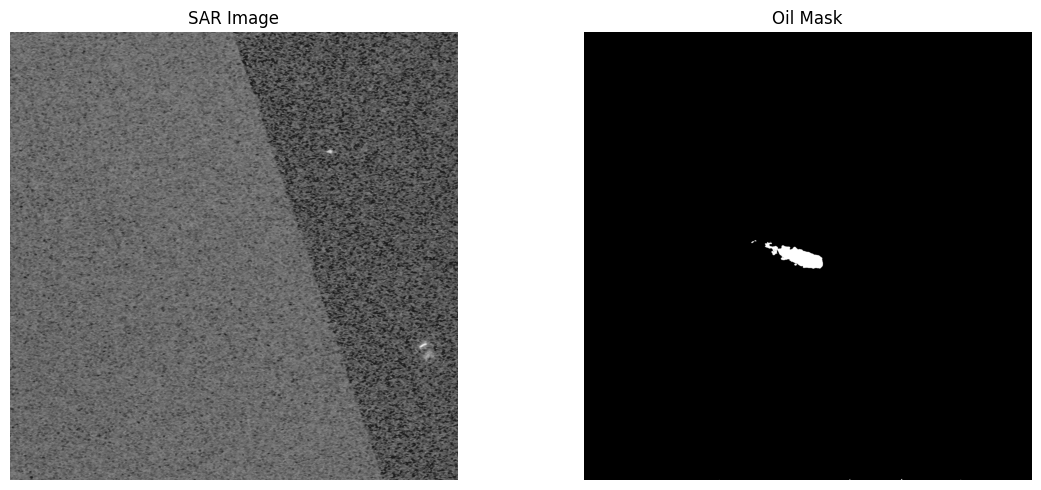

In [12]:
# ==========================================
# VISUAL IMAGE + MASK CHECK
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import os

# Oil category से एक sample
sample = next(
    p for p in pairs
    if p["class"] == "Oil"
)

# Read image
with rasterio.open(sample["image"]) as src:
    image = src.read()

# Read mask
with rasterio.open(sample["mask"]) as src:
    mask = src.read(1)

print("Image:", os.path.basename(sample["image"]))
print("Image shape:", image.shape)
print("Mask shape :", mask.shape)
print("Mask values:", np.unique(mask))

# Display first SAR band
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image[0], cmap="gray")
plt.title("SAR Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Oil Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# U-NET MODEL
# ==========================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet(
    in_channels=2,
    out_channels=1
).to(device)

print("Device:", device)
print("Model created successfully.")

Device: cuda
Model created successfully.


In [15]:
# ==========================================
# DICE + BCE LOSS
# ==========================================

class DiceBCELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets):

        bce_loss = self.bce(inputs, targets)

        probs = torch.sigmoid(inputs)

        smooth = 1.0

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            (2.0 * intersection + smooth)
            /
            (probs.sum() + targets.sum() + smooth)
        )

        dice_loss = 1.0 - dice

        return bce_loss + dice_loss


criterion = DiceBCELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: DiceBCELoss(
  (bce): BCEWithLogitsLoss()
)
Optimizer: AdamW


In [16]:
BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 48
Val batches: 15


In [17]:
# ==========================================
# MODEL FORWARD TEST
# ==========================================

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", outputs.shape)

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be051c62de0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.13/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/usr/lib/python3.13/multiprocessing/popen_fork.py", line 41, in wait
    if not wait([self.sentinel], timeout):
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 1174, in w

Input shape : torch.Size([1, 2, 512, 512])
Mask shape  : torch.Size([1, 512, 512])
Output shape: torch.Size([1, 1, 512, 512])


In [18]:
# ==========================================
# TRAINING CONFIGURATION
# ==========================================

EPOCHS = 30
LEARNING_RATE = 1e-4

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Device:", device)

Epochs: 30
Learning rate: 0.0001
Device: cuda


In [19]:
# ==========================================
# DICE SCORE
# ==========================================

def dice_score(logits, targets, threshold=0.5):

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.unsqueeze(1).view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + 1.0)
        /
        (preds.sum(dim=1) + targets.sum(dim=1) + 1.0)
    )

    return dice.mean().item()

In [20]:
# ==========================================
# U-NET TRAINING
# ==========================================

from tqdm.auto import tqdm

best_val_dice = -1.0
best_val_loss = float("inf")

train_losses = []
val_losses = []
val_dices = []

patience = 7
patience_counter = 0

# Mixed precision for CUDA
use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

for epoch in range(EPOCHS):

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()

    running_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"
    )

    for images, masks in train_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            outputs = model(images)

            # [B, 1, H, W] → [B, H, W]
            outputs_for_loss = outputs.squeeze(1)

            loss = criterion(
                outputs_for_loss,
                masks
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    running_val_dice = 0.0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"
        )

        for images, masks in val_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                enabled=use_amp
            ):

                outputs = model(images)

                outputs_for_loss = outputs.squeeze(1)

                loss = criterion(
                    outputs_for_loss,
                    masks
                )

            dice = dice_score(
                outputs,
                masks
            )

            running_val_loss += loss.item()
            running_val_dice += dice

    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )

    avg_val_dice = (
        running_val_dice /
        len(val_loader)
    )

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_dices.append(avg_val_dice)

    print(
        f"\nEpoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Dice: {avg_val_dice:.4f}"
    )

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if avg_val_dice > best_val_dice:

        best_val_dice = avg_val_dice
        best_val_loss = avg_val_loss
        patience_counter = 0

        print(
            f"✅ New best model! "
            f"Validation Dice: {best_val_dice:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"No improvement: "
            f"{patience_counter}/{patience}"
        )

    # -------------------------
    # EARLY STOPPING
    # -------------------------
    if patience_counter >= patience:

        print("\n⏹️ Early stopping triggered.")
        break

print("\n========== TRAINING COMPLETE ==========")
print("Best Validation Dice:", best_val_dice)

Epoch 1/30 [Train]:   0%|          | 0/48 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 1/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =


Epoch [1/30] Train Loss: 1.4370 | Val Loss: 1.6119 | Val Dice: 0.1805
✅ New best model! Validation Dice: 0.1805


...

Epoch 17/30 [Train]:   0%|          | 0/48 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 17/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =


Epoch [17/30] Train Loss: 0.9330 | Val Loss: 1.0389 | Val Dice: 0.3372
No improvement: 7/7

⏹️ Early stopping triggered.

========== TRAINING COMPLETE ==========
Best Validation Dice: 0.7834181335056201


In [22]:
# ==========================================
# BEST MODEL CHECKPOINT TRAINING
# ==========================================

MODEL_DIR = "/content/VARUN/models/phase1"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "unet_oil_spill_v0.1.pth"
)

print("Best model path:")
print(BEST_MODEL_PATH)

# Reset model and optimizer before fresh training
model = UNet(
    in_channels=2,
    out_channels=1
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

EPOCHS = 30
patience = 7

best_val_dice = -1.0
patience_counter = 0

train_losses = []
val_losses = []
val_dices = []

use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

for epoch in range(EPOCHS):

    # ==========================
    # TRAIN
    # ==========================
    model.train()

    running_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"
    )

    for images, masks in train_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            outputs = model(images)

            loss = criterion(
                outputs.squeeze(1),
                masks
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    running_val_loss = 0.0
    running_val_dice = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                enabled=use_amp
            ):

                outputs = model(images)

                loss = criterion(
                    outputs.squeeze(1),
                    masks
                )

            dice = dice_score(
                outputs,
                masks
            )

            running_val_loss += loss.item()
            running_val_dice += dice

    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )

    avg_val_dice = (
        running_val_dice /
        len(val_loader)
    )

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_dices.append(avg_val_dice)

    print(
        f"\nEpoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Dice: {avg_val_dice:.4f}"
    )

    # ==========================
    # SAVE BEST MODEL
    # ==========================
    if avg_val_dice > best_val_dice:

        best_val_dice = avg_val_dice
        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"✅ Best model saved!"
            f" Val Dice: {best_val_dice:.4f}"
        )
        print(
            f"📁 {BEST_MODEL_PATH}"
        )

    else:

        patience_counter += 1

        print(
            f"No improvement: "
            f"{patience_counter}/{patience}"
        )

    # ==========================
    # EARLY STOPPING
    # ==========================
    if patience_counter >= patience:

        print("\n⏹️ Early stopping triggered.")
        break

print("\n========== TRAINING COMPLETE ==========")
print(
    f"Best Validation Dice: "
    f"{best_val_dice:.4f}"
)
print(
    f"Best model saved at:\n"
    f"{BEST_MODEL_PATH}"
)

Best model path:
/content/VARUN/models/phase1/unet_oil_spill_v0.1.pth


Epoch 1/30 [Train]:   0%|          | 0/48 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =


Epoch [1/30] Train Loss: 1.5792 | Val Loss: 1.4850 | Val Dice: 0.2854
✅ Best model saved! Val Dice: 0.2854
📁 /content/VARUN/models/phase1/unet_oil_spill_v0.1.pth


Epoch 2/30 [Train]:   0%|          | 0/48 [00:00<?, ?it/s]

...

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =


Epoch [12/30] Train Loss: 1.0817 | Val Loss: 1.0964 | Val Dice: 0.8071
No improvement: 6/7


Epoch 13/30 [Train]:   0%|          | 0/48 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =


Epoch [13/30] Train Loss: 1.0641 | Val Loss: 1.0699 | Val Dice: 0.5034
No improvement: 7/7

⏹️ Early stopping triggered.

========== TRAINING COMPLETE ==========
Best Validation Dice: 0.8739
Best model saved at:
/content/VARUN/models/phase1/unet_oil_spill_v0.1.pth


In [23]:
# ==========================================
# LOAD BEST TRAINED MODEL
# ==========================================

BEST_MODEL_PATH = "/content/VARUN/models/phase1/unet_oil_spill_v0.1.pth"

model = UNet(
    in_channels=2,
    out_channels=1
).to(device)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✅ Best model loaded successfully!")
print("Model:", BEST_MODEL_PATH)

✅ Best model loaded successfully!
Model: /content/VARUN/models/phase1/unet_oil_spill_v0.1.pth


In [24]:
# ==========================================
# PREDICTION ON ONE VALIDATION IMAGE
# ==========================================

sample = val_pairs[0]

with rasterio.open(sample["image"]) as src:
    image = src.read().astype(np.float32)

with rasterio.open(sample["mask"]) as src:
    ground_truth = src.read(1).astype(np.float32)

# Normalize each SAR band
for b in range(image.shape[0]):

    band = image[b]

    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    if high > low:
        image[b] = np.clip(
            (band - low) / (high - low),
            0,
            1
        )
    else:
        image[b] = 0

# Convert to tensor
image_tensor = torch.from_numpy(image)

# Resize to 512x512
image_tensor = torch.nn.functional.interpolate(
    image_tensor.unsqueeze(0),
    size=(512, 512),
    mode="bilinear",
    align_corners=False
)

# Prediction
image_tensor = image_tensor.to(device)

with torch.no_grad():
    output = model(image_tensor)

prediction = torch.sigmoid(output)

prediction = prediction.squeeze().cpu().numpy()

# Binary mask
predicted_mask = (prediction > 0.5).astype(np.uint8)

print("Image:", os.path.basename(sample["image"]))
print("Prediction shape:", predicted_mask.shape)
print("Predicted unique values:", np.unique(predicted_mask))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Image: 00000.tif
Prediction shape: (512, 512)
Predicted unique values: [0 1]


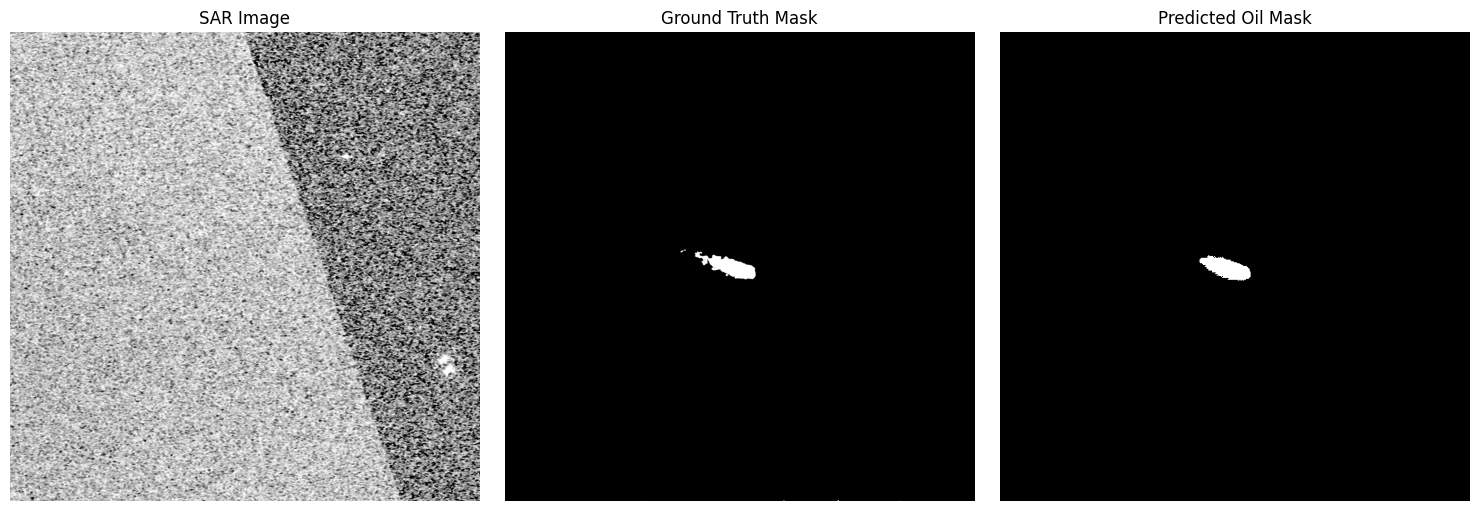

In [25]:
# ==========================================
# VISUAL COMPARISON
# ==========================================

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(image[0], cmap="gray")
plt.title("SAR Image")
plt.axis("off")

# Ground truth
plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Oil Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# ==========================================
# QUANTITATIVE PREDICTION METRICS
# ==========================================

import torch.nn.functional as F

# Ground truth ko 512x512 resize karo
gt_tensor = torch.from_numpy(
    ground_truth
).float().unsqueeze(0).unsqueeze(0)

gt_tensor = F.interpolate(
    gt_tensor,
    size=(512, 512),
    mode="nearest"
)

gt_mask = (
    gt_tensor.squeeze().numpy() > 0.5
).astype(np.uint8)

pred_mask = predicted_mask.astype(np.uint8)

# Flatten
gt = gt_mask.flatten()
pred = pred_mask.flatten()

# Confusion values
TP = np.sum((pred == 1) & (gt == 1))
TN = np.sum((pred == 0) & (gt == 0))
FP = np.sum((pred == 1) & (gt == 0))
FN = np.sum((pred == 0) & (gt == 1))

# Dice
dice = (
    2 * TP
    /
    (2 * TP + FP + FN + 1e-8)
)

# IoU
iou = (
    TP
    /
    (TP + FP + FN + 1e-8)
)

# Precision
precision = (
    TP
    /
    (TP + FP + 1e-8)
)

# Recall
recall = (
    TP
    /
    (TP + FN + 1e-8)
)

print("========== PREDICTION METRICS ==========")

print(f"TP        : {TP}")
print(f"TN        : {TN}")
print(f"FP        : {FP}")
print(f"FN        : {FN}")

print(f"\nDice      : {dice:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

========== PREDICTION METRICS ==========
TP        : 802
TN        : 261133
FP        : 106
FN        : 103

Dice      : 0.8847
IoU       : 0.7933
Precision : 0.8833
Recall    : 0.8862


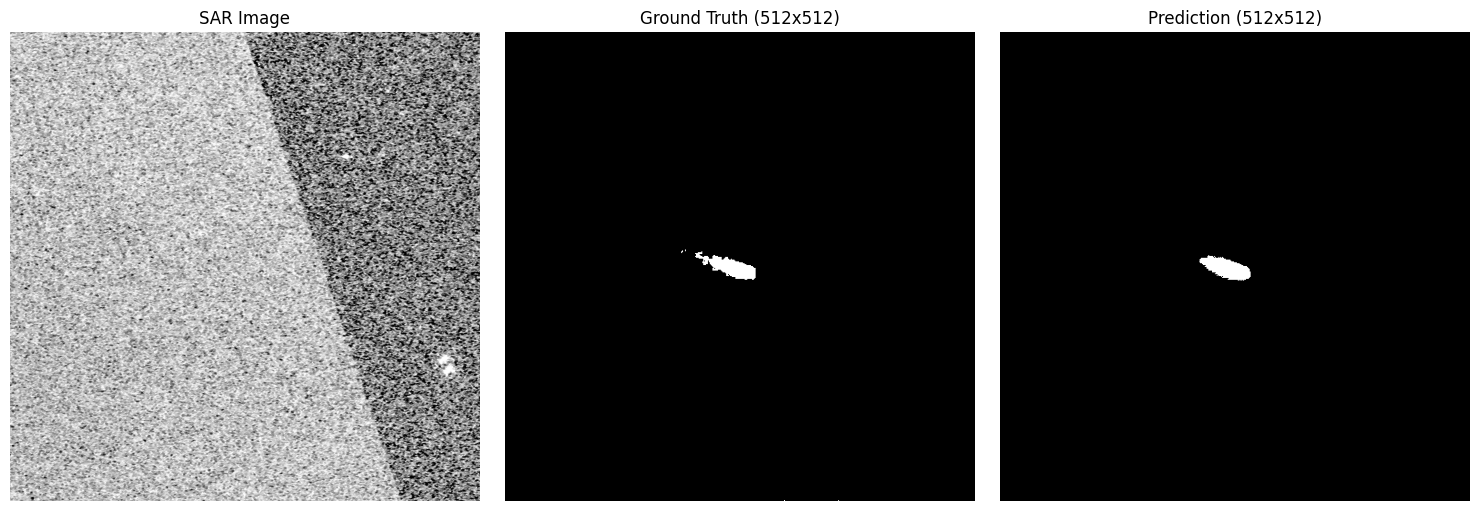

In [27]:
# ==========================================
# ALIGNED VISUAL COMPARISON
# ==========================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image[0], cmap="gray")
plt.title("SAR Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth (512x512)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction (512x512)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# COMPLETE VALIDATION EVALUATION
# ==========================================

model.eval()

all_dice = []
all_iou = []
all_precision = []
all_recall = []

with torch.no_grad():

    for sample in val_pairs:

        # -------------------------
        # Read image
        # -------------------------
        with rasterio.open(sample["image"]) as src:
            image = src.read().astype(np.float32)

        # -------------------------
        # Read ground truth
        # -------------------------
        with rasterio.open(sample["mask"]) as src:
            ground_truth = src.read(1).astype(np.float32)

        # -------------------------
        # Normalize SAR bands
        # -------------------------
        for b in range(image.shape[0]):

            band = image[b]

            low = np.percentile(band, 2)
            high = np.percentile(band, 98)

            if high > low:
                image[b] = np.clip(
                    (band - low) / (high - low),
                    0,
                    1
                )
            else:
                image[b] = 0

        # -------------------------
        # Image → 512x512
        # -------------------------
        image_tensor = torch.from_numpy(image)

        image_tensor = F.interpolate(
            image_tensor.unsqueeze(0),
            size=(512, 512),
            mode="bilinear",
            align_corners=False
        ).to(device)

        # -------------------------
        # Ground truth → 512x512
        # -------------------------
        gt_tensor = torch.from_numpy(
            ground_truth
        ).float().unsqueeze(0).unsqueeze(0)

        gt_tensor = F.interpolate(
            gt_tensor,
            size=(512, 512),
            mode="nearest"
        )

        gt = (
            gt_tensor.squeeze().numpy() > 0.5
        ).astype(np.uint8)

        # -------------------------
        # Prediction
        # -------------------------
        output = model(image_tensor)

        prediction = torch.sigmoid(output)

        pred = (
            prediction.squeeze().cpu().numpy() > 0.5
        ).astype(np.uint8)

        # -------------------------
        # Metrics
        # -------------------------
        gt_flat = gt.flatten()
        pred_flat = pred.flatten()

        TP = np.sum(
            (pred_flat == 1) &
            (gt_flat == 1)
        )

        FP = np.sum(
            (pred_flat == 1) &
            (gt_flat == 0)
        )

        FN = np.sum(
            (pred_flat == 0) &
            (gt_flat == 1)
        )

        dice = (
            2 * TP /
            (2 * TP + FP + FN + 1e-8)
        )

        iou = (
            TP /
            (TP + FP + FN + 1e-8)
        )

        precision = (
            TP /
            (TP + FP + 1e-8)
        )

        recall = (
            TP /
            (TP + FN + 1e-8)
        )

        all_dice.append(dice)
        all_iou.append(iou)
        all_precision.append(precision)
        all_recall.append(recall)

        print(
            f"{os.path.basename(sample['image']):12} | "
            f"{sample['class']:18} | "
            f"Dice: {dice:.4f} | "
            f"IoU: {iou:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f}"
        )


# ==========================================
# FINAL AVERAGE
# ==========================================

print("\n========== FINAL VALIDATION RESULTS ==========")

print(
    f"Average Dice      : {np.mean(all_dice):.4f}"
)

print(
    f"Average IoU       : {np.mean(all_iou):.4f}"
)

print(
    f"Average Precision : {np.mean(all_precision):.4f}"
)

print(
    f"Average Recall    : {np.mean(all_recall):.4f}"
)

print(
    f"\nValidation Images : {len(val_pairs)}"
)

00000.tif    | Oil                | Dice: 0.8847 | IoU: 0.7933 | Precision: 0.8833 | Recall: 0.8862


00017.tif    | Oil                | Dice: 0.9176 | IoU: 0.8477 | Precision: 0.9195 | Recall: 0.9156


00015.tif    | Oil                | Dice: 0.7861 | IoU: 0.6475 | Precision: 0.9616 | Recall: 0.6647


00001.tif    | Oil                | Dice: 0.9412 | IoU: 0.8889 | Precision: 0.9614 | Recall: 0.9218


00008.tif    | Oil                | Dice: 0.5785 | IoU: 0.4070 | Precision: 0.9822 | Recall: 0.4100


...

00008.tif    | No_Oil             | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000


00000.tif    | Oil_Look_Alike     | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000


00017.tif    | Oil_Look_Alike     | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000


00015.tif    | Oil_Look_Alike     | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000


00001.tif    | Oil_Look_Alike     | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000
00008.tif    | Oil_Look_Alike     | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000

========== FINAL VALIDATION RESULTS ==========
Average Dice      : 0.2739
Average IoU       : 0.2390
Average Precision : 0.3139
Average Recall    : 0.2532

Validation Images : 15


In [29]:
# ==========================================
# CORRECTED VALIDATION EVALUATION
# ==========================================

model.eval()

results = []

with torch.no_grad():

    for sample in val_pairs:

        # -------------------------
        # Read image
        # -------------------------
        with rasterio.open(sample["image"]) as src:
            image = src.read().astype(np.float32)

        # -------------------------
        # Read mask
        # -------------------------
        with rasterio.open(sample["mask"]) as src:
            ground_truth = src.read(1).astype(np.float32)

        # -------------------------
        # Normalize image
        # -------------------------
        for b in range(image.shape[0]):

            band = image[b]

            low = np.percentile(band, 2)
            high = np.percentile(band, 98)

            if high > low:
                image[b] = np.clip(
                    (band - low) / (high - low),
                    0,
                    1
                )
            else:
                image[b] = 0

        # -------------------------
        # Image → 512x512
        # -------------------------
        image_tensor = torch.from_numpy(image)

        image_tensor = F.interpolate(
            image_tensor.unsqueeze(0),
            size=(512, 512),
            mode="bilinear",
            align_corners=False
        ).to(device)

        # -------------------------
        # Ground Truth → 512x512
        # -------------------------
        gt_tensor = torch.from_numpy(
            ground_truth
        ).float().unsqueeze(0).unsqueeze(0)

        gt_tensor = F.interpolate(
            gt_tensor,
            size=(512, 512),
            mode="nearest"
        )

        gt = (
            gt_tensor.squeeze().numpy() > 0.5
        ).astype(np.uint8)

        # -------------------------
        # Prediction
        # -------------------------
        output = model(image_tensor)

        prediction = torch.sigmoid(output)

        pred = (
            prediction.squeeze().cpu().numpy() > 0.5
        ).astype(np.uint8)

        # -------------------------
        # Confusion matrix
        # -------------------------
        gt_flat = gt.flatten()
        pred_flat = pred.flatten()

        TP = np.sum(
            (pred_flat == 1) &
            (gt_flat == 1)
        )

        TN = np.sum(
            (pred_flat == 0) &
            (gt_flat == 0)
        )

        FP = np.sum(
            (pred_flat == 1) &
            (gt_flat == 0)
        )

        FN = np.sum(
            (pred_flat == 0) &
            (gt_flat == 1)
        )

        # -------------------------
        # Correct Dice handling
        # -------------------------
        if (TP + FP + FN) == 0:
            dice = 1.0
            iou = 1.0
        else:
            dice = (
                2 * TP /
                (2 * TP + FP + FN)
            )

            iou = (
                TP /
                (TP + FP + FN)
            )

        # -------------------------
        # Precision / Recall
        # -------------------------
        if (TP + FP) == 0:
            precision = 1.0 if (TP + FN) == 0 else 0.0
        else:
            precision = TP / (TP + FP)

        if (TP + FN) == 0:
            recall = 1.0
        else:
            recall = TP / (TP + FN)

        results.append({
            "class": sample["class"],
            "image": os.path.basename(sample["image"]),
            "dice": dice,
            "iou": iou,
            "precision": precision,
            "recall": recall
        })

        print(
            f"{sample['class']:18} | "
            f"{os.path.basename(sample['image']):12} | "
            f"Dice: {dice:.4f} | "
            f"IoU: {iou:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f}"
        )


# ==========================================
# CLASS-WISE RESULTS
# ==========================================

print("\n========== CLASS-WISE RESULTS ==========")

for class_name in [
    "Oil",
    "No_Oil",
    "Oil_Look_Alike"
]:

    class_results = [
        r for r in results
        if r["class"] == class_name
    ]

    print(f"\n--- {class_name} ---")

    print(
        f"Images    : {len(class_results)}"
    )

    print(
        f"Dice      : "
        f"{np.mean([r['dice'] for r in class_results]):.4f}"
    )

    print(
        f"IoU       : "
        f"{np.mean([r['iou'] for r in class_results]):.4f}"
    )

    print(
        f"Precision : "
        f"{np.mean([r['precision'] for r in class_results]):.4f}"
    )

    print(
        f"Recall    : "
        f"{np.mean([r['recall'] for r in class_results]):.4f}"
    )


# ==========================================
# OVERALL RESULTS
# ==========================================

print("\n========== OVERALL VALIDATION ==========")

print(
    f"Average Dice      : "
    f"{np.mean([r['dice'] for r in results]):.4f}"
)

print(
    f"Average IoU       : "
    f"{np.mean([r['iou'] for r in results]):.4f}"
)

print(
    f"Average Precision : "
    f"{np.mean([r['precision'] for r in results]):.4f}"
)

print(
    f"Average Recall    : "
    f"{np.mean([r['recall'] for r in results]):.4f}"
)

print(
    f"Validation Images : {len(results)}"
)

Oil                | 00000.tif    | Dice: 0.8847 | IoU: 0.7933 | Precision: 0.8833 | Recall: 0.8862


Oil                | 00017.tif    | Dice: 0.9176 | IoU: 0.8477 | Precision: 0.9195 | Recall: 0.9156


Oil                | 00015.tif    | Dice: 0.7861 | IoU: 0.6475 | Precision: 0.9616 | Recall: 0.6647


Oil                | 00001.tif    | Dice: 0.9412 | IoU: 0.8889 | Precision: 0.9614 | Recall: 0.9218


Oil                | 00008.tif    | Dice: 0.5785 | IoU: 0.4070 | Precision: 0.9822 | Recall: 0.4100


...

No_Oil             | 00008.tif    | Dice: 1.0000 | IoU: 1.0000 | Precision: 1.0000 | Recall: 1.0000


Oil_Look_Alike     | 00000.tif    | Dice: 1.0000 | IoU: 1.0000 | Precision: 1.0000 | Recall: 1.0000


Oil_Look_Alike     | 00017.tif    | Dice: 1.0000 | IoU: 1.0000 | Precision: 1.0000 | Recall: 1.0000


Oil_Look_Alike     | 00015.tif    | Dice: 1.0000 | IoU: 1.0000 | Precision: 1.0000 | Recall: 1.0000


Oil_Look_Alike     | 00001.tif    | Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 1.0000
Oil_Look_Alike     | 00008.tif    | Dice: 1.0000 | IoU: 1.0000 | Precision: 1.0000 | Recall: 1.0000

========== CLASS-WISE RESULTS ==========

--- Oil ---
Images    : 5
Dice      : 0.8216
IoU       : 0.7169
Precision : 0.9416
Recall    : 0.7597

--- No_Oil ---
Images    : 5
Dice      : 1.0000
IoU       : 1.0000
Precision : 1.0000
Recall    : 1.0000

--- Oil_Look_Alike ---
Images    : 5
Dice      : 0.8000
IoU       : 0.8000
Precision : 0.8000
Recall    : 1.0000

========== OVERALL VALIDATION ==========
Average Dice      : 0.8739
Average IoU       : 0.8390
Average Precision : 0.9139
Average Recall    : 0.9199
Validation Images : 15


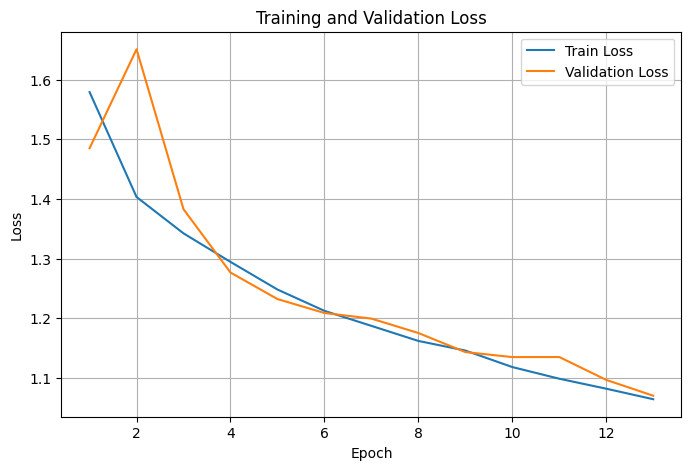

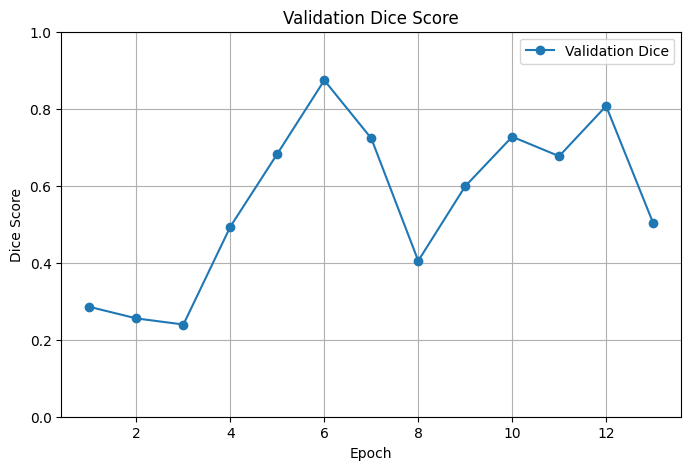

Best Validation Dice: 0.8738663322796735
Best Epoch: 6


In [30]:
# ==========================================
# TRAINING GRAPHS
# ==========================================

import matplotlib.pyplot as plt

epochs_completed = range(1, len(train_losses) + 1)

# Train vs Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_losses,
    label="Train Loss"
)

plt.plot(
    epochs_completed,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# Validation Dice
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    val_dices,
    marker="o",
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

print("Best Validation Dice:", max(val_dices))
print(
    "Best Epoch:",
    np.argmax(val_dices) + 1
)

In [31]:
# ==========================================
# VISUAL PREDICTION
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import rasterio
import os

# Load best model again
BEST_MODEL_PATH = "/content/VARUN/models/phase1/unet_oil_spill_v0.1.pth"

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✅ Best model loaded")

# Show first 5 validation samples
samples_to_show = val_pairs[:5]

for sample in samples_to_show:

    # -------------------------
    # Read image
    # -------------------------
    with rasterio.open(sample["image"]) as src:
        image = src.read().astype(np.float32)

    # -------------------------
    # Read ground truth
    # -------------------------
    with rasterio.open(sample["mask"]) as src:
        ground_truth = src.read(1).astype(np.float32)

    # -------------------------
    # Normalize image
    # -------------------------
    for b in range(image.shape[0]):

        band = image[b]

        low = np.percentile(band, 2)
        high = np.percentile(band, 98)

        if high > low:
            image[b] = np.clip(
                (band - low) / (high - low),
                0,
                1
            )
        else:
            image[b] = 0

    # -------------------------
    # Resize image
    # -------------------------
    image_tensor = torch.from_numpy(image)

    image_tensor = F.interpolate(
        image_tensor.unsqueeze(0),
        size=(512, 512),
        mode="bilinear",
        align_corners=False
    ).to(device)

    # -------------------------
    # Prediction
    # -------------------------
    with torch.no_grad():

        output = model(image_tensor)

        probability = torch.sigmoid(output)

        predicted_mask = (
            probability.squeeze().cpu().numpy() > 0.5
        ).astype(np.uint8)

    # -------------------------
    # Resize ground truth
    # -------------------------
    gt_tensor = torch.from_numpy(
        ground_truth
    ).float().unsqueeze(0).unsqueeze(0)

    gt_tensor = F.interpolate(
        gt_tensor,
        size=(512, 512),
        mode="nearest"
    )

    gt_mask = (
        gt_tensor.squeeze().numpy() > 0.5
    ).astype(np.uint8)

    # -------------------------
    # Display
    # -------------------------
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image[0], cmap="gray")
    plt.title(
        f"SAR Image\n{sample['class']} - "
        f"{os.path.basename(sample['image'])}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Predicted Oil Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
========== FILE CHECK ==========
Test image exists : True
Model exists      : True

✅ Best Phase 1 U-Net model loaded



========== TEST IMAGE ==========
Filename : 00168.tif
Shape    : (2, 2048, 2048)
Width    : 2048
Height   : 2048
Bands    : 2
✅ 2 SAR bands confirmed

Model input shape: torch.Size([1, 2, 512, 512])

========== PHASE 1 RESULT ==========
Predicted mask shape : (512, 512)
Oil pixels           : 4784
Total pixels         : 262144
Predicted oil area   : 1.8250%
🚨 RESULT: Potential Oil Spill Detected


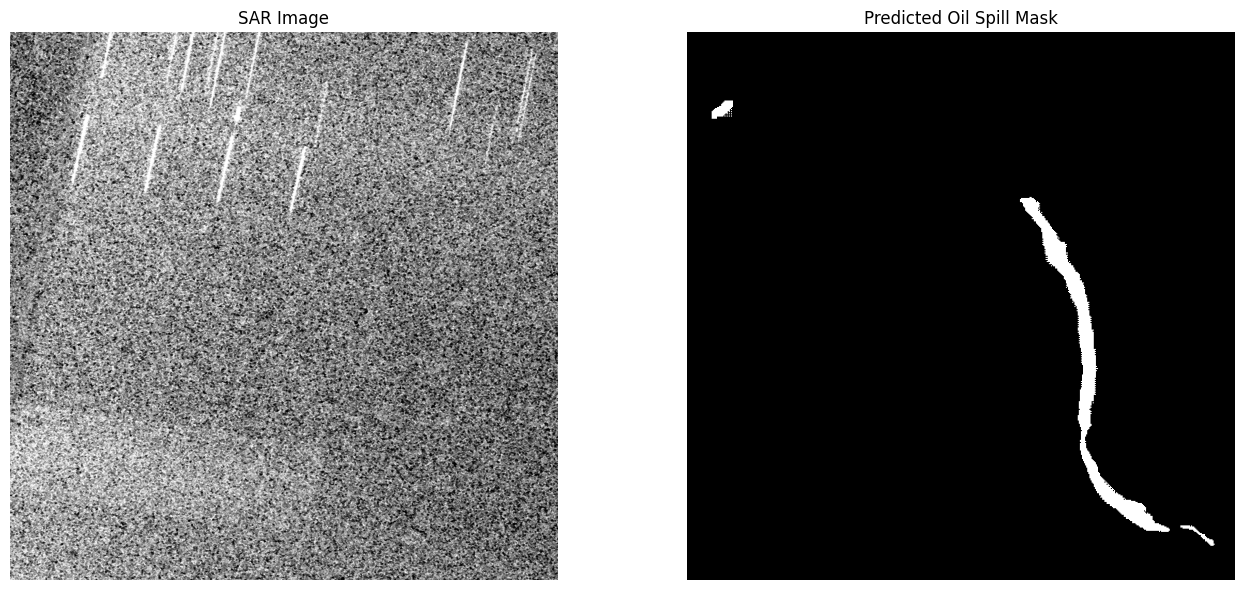

In [36]:
# ==========================================
# PHASE 1 - FINAL INFERENCE
# ==========================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


# ==========================================
# 2. IMPORTS
# ==========================================

import os
import numpy as np
import torch
import torch.nn.functional as F
import rasterio
import matplotlib.pyplot as plt


# ==========================================
# 3. PATHS
# ==========================================

TEST_IMAGE = "/content/drive/MyDrive/00168.tif"

BEST_MODEL = "/content/VARUN/models/phase1/unet_oil_spill_v0.1.pth"


# ==========================================
# 4. CHECK FILES
# ==========================================

print("========== FILE CHECK ==========")

print(
    "Test image exists :",
    os.path.exists(TEST_IMAGE)
)

print(
    "Model exists      :",
    os.path.exists(BEST_MODEL)
)

if not os.path.exists(TEST_IMAGE):
    raise FileNotFoundError(
        f"Test image not found:\n{TEST_IMAGE}"
    )

if not os.path.exists(BEST_MODEL):
    raise FileNotFoundError(
        f"Model not found:\n{BEST_MODEL}"
    )


# ==========================================
# 5. LOAD MODEL
# ==========================================

model.load_state_dict(
    torch.load(
        BEST_MODEL,
        map_location=device
    )
)

model.to(device)
model.eval()

print("\n✅ Best Phase 1 U-Net model loaded")


# ==========================================
# 6. READ TEST SAR IMAGE
# ==========================================

with rasterio.open(TEST_IMAGE) as src:

    test_image = src.read().astype(
        np.float32
    )

    print("\n========== TEST IMAGE ==========")

    print(
        "Filename :",
        os.path.basename(TEST_IMAGE)
    )

    print(
        "Shape    :",
        test_image.shape
    )

    print(
        "Width    :",
        src.width
    )

    print(
        "Height   :",
        src.height
    )

    print(
        "Bands    :",
        src.count
    )


# ==========================================
# 7. CHECK SAR BANDS
# ==========================================

if test_image.shape[0] != 2:

    raise ValueError(
        f"Expected 2 SAR bands, "
        f"but found {test_image.shape[0]} bands."
    )

print("✅ 2 SAR bands confirmed")


# ==========================================
# 8. NORMALIZATION
# Same preprocessing used during training
# ==========================================

for b in range(test_image.shape[0]):

    band = test_image[b]

    low = np.percentile(
        band,
        2
    )

    high = np.percentile(
        band,
        98
    )

    if high > low:

        test_image[b] = np.clip(
            (band - low) / (high - low),
            0,
            1
        )

    else:

        test_image[b] = 0


# ==========================================
# 9. RESIZE TO 512 × 512
# ==========================================

image_tensor = torch.from_numpy(
    test_image
)

image_tensor = F.interpolate(
    image_tensor.unsqueeze(0),
    size=(512, 512),
    mode="bilinear",
    align_corners=False
)

image_tensor = image_tensor.to(device)

print(
    "\nModel input shape:",
    image_tensor.shape
)


# ==========================================
# 10. MODEL PREDICTION
# ==========================================

with torch.no_grad():

    output = model(
        image_tensor
    )

    probability = torch.sigmoid(
        output
    )

    predicted_mask = (
        probability
        .squeeze()
        .cpu()
        .numpy() > 0.5
    ).astype(np.uint8)


# ==========================================
# 11. CALCULATE OIL AREA
# ==========================================

oil_pixels = int(
    predicted_mask.sum()
)

total_pixels = int(
    predicted_mask.size
)

oil_percentage = (
    oil_pixels /
    total_pixels
) * 100


# ==========================================
# 12. FINAL RESULT
# ==========================================

print("\n========== PHASE 1 RESULT ==========")

print(
    "Predicted mask shape :",
    predicted_mask.shape
)

print(
    "Oil pixels           :",
    oil_pixels
)

print(
    "Total pixels         :",
    total_pixels
)

print(
    "Predicted oil area   :",
    f"{oil_percentage:.4f}%"
)

if oil_pixels > 0:

    print(
        "🚨 RESULT: Potential Oil Spill Detected"
    )

else:

    print(
        "✅ RESULT: No Oil Spill Detected"
    )


# ==========================================
# 13. VISUALIZATION
# ==========================================

plt.figure(
    figsize=(14, 6)
)

# SAR image
plt.subplot(1, 2, 1)

plt.imshow(
    test_image[0],
    cmap="gray"
)

plt.title(
    "SAR Image"
)

plt.axis("off")


# Predicted mask
plt.subplot(1, 2, 2)

plt.imshow(
    predicted_mask,
    cmap="gray"
)

plt.title(
    "Predicted Oil Spill Mask"
)

plt.axis("off")

plt.tight_layout()

plt.show()

========== FILE CHECK ==========
Test image exists : True
Model exists      : True



✅ Best Phase 1 U-Net loaded

========== INPUT IMAGE ==========
Shape : (2, 2048, 2048)
Width : 2048
Height: 2048
Bands : 2
✅ 2 SAR bands confirmed

========== TILING ==========
Tile size : 512
Rows      : 4
Columns   : 4
Total tiles: 16
Tile 01/16 completed
Tile 02/16 completed
Tile 03/16 completed
Tile 04/16 completed
Tile 05/16 completed
Tile 06/16 completed
Tile 07/16 completed
Tile 08/16 completed
Tile 09/16 completed
Tile 10/16 completed
Tile 11/16 completed
Tile 12/16 completed
Tile 13/16 completed
Tile 14/16 completed
Tile 15/16 completed
Tile 16/16 completed

========== FINAL TILE RESULT ==========
Final mask shape : (2048, 2048)
Oil pixels       : 50031
Total pixels     : 4194304
Predicted oil area: 1.1928%
🚨 RESULT: Potential Oil Spill Detected

✅ Final mask saved:
/content/drive/MyDrive/00168_oil_spill_mask.tif


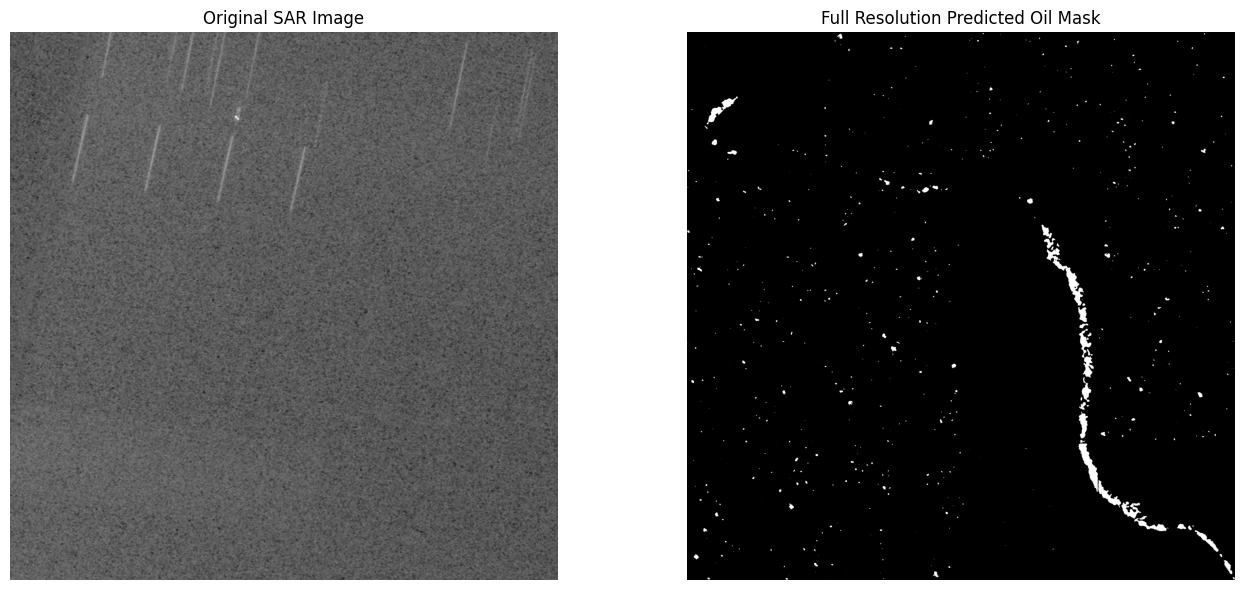

In [37]:
# ==========================================
# PHASE 1 - TILE BASED INFERENCE
# 2048x2048 -> 512x512 tiles
# ==========================================

import os
import numpy as np
import torch
import torch.nn.functional as F
import rasterio
import matplotlib.pyplot as plt

# ==========================================
# PATHS
# ==========================================

TEST_IMAGE = "/content/drive/MyDrive/00168.tif"

BEST_MODEL = "/content/VARUN/models/phase1/unet_oil_spill_v0.1.pth"

OUTPUT_MASK = "/content/drive/MyDrive/00168_oil_spill_mask.tif"


# ==========================================
# CHECK
# ==========================================

print("========== FILE CHECK ==========")

print("Test image exists :", os.path.exists(TEST_IMAGE))
print("Model exists      :", os.path.exists(BEST_MODEL))

if not os.path.exists(TEST_IMAGE):
    raise FileNotFoundError(TEST_IMAGE)

if not os.path.exists(BEST_MODEL):
    raise FileNotFoundError(BEST_MODEL)


# ==========================================
# LOAD MODEL
# ==========================================

model.load_state_dict(
    torch.load(
        BEST_MODEL,
        map_location=device
    )
)

model.to(device)
model.eval()

print("\n✅ Best Phase 1 U-Net loaded")


# ==========================================
# READ FULL IMAGE
# ==========================================

with rasterio.open(TEST_IMAGE) as src:

    full_image = src.read().astype(np.float32)

    profile = src.profile.copy()

    height = src.height
    width = src.width
    bands = src.count

print("\n========== INPUT IMAGE ==========")

print("Shape :", full_image.shape)
print("Width :", width)
print("Height:", height)
print("Bands :", bands)


# ==========================================
# CHECK 2 BANDS
# ==========================================

if bands != 2:

    raise ValueError(
        f"Expected 2 bands, found {bands}"
    )

print("✅ 2 SAR bands confirmed")


# ==========================================
# TILE SETTINGS
# ==========================================

TILE_SIZE = 512

if height % TILE_SIZE != 0 or width % TILE_SIZE != 0:

    raise ValueError(
        "Image dimensions must be divisible by 512 "
        "for this version."
    )

rows = height // TILE_SIZE
cols = width // TILE_SIZE

print("\n========== TILING ==========")

print("Tile size :", TILE_SIZE)
print("Rows      :", rows)
print("Columns   :", cols)
print("Total tiles:", rows * cols)


# ==========================================
# OUTPUT MASK
# ==========================================

final_mask = np.zeros(
    (height, width),
    dtype=np.uint8
)


# ==========================================
# PROCESS TILES
# ==========================================

tile_number = 0

for row in range(rows):

    for col in range(cols):

        tile_number += 1

        y1 = row * TILE_SIZE
        y2 = y1 + TILE_SIZE

        x1 = col * TILE_SIZE
        x2 = x1 + TILE_SIZE

        # -----------------------------
        # Extract tile
        # -----------------------------

        tile = full_image[
            :,
            y1:y2,
            x1:x2
        ].copy()

        # -----------------------------
        # Normalize exactly as training
        # -----------------------------

        for b in range(2):

            band = tile[b]

            low = np.percentile(
                band,
                2
            )

            high = np.percentile(
                band,
                98
            )

            if high > low:

                tile[b] = np.clip(
                    (band - low) / (high - low),
                    0,
                    1
                )

            else:

                tile[b] = 0

        # -----------------------------
        # Tensor
        # -----------------------------

        tile_tensor = torch.from_numpy(
            tile
        ).unsqueeze(0).to(device)

        # -----------------------------
        # Prediction
        # -----------------------------

        with torch.no_grad():

            output = model(
                tile_tensor
            )

            probability = torch.sigmoid(
                output
            )

            prediction = (
                probability
                .squeeze()
                .cpu()
                .numpy() > 0.5
            ).astype(np.uint8)

        # -----------------------------
        # Put prediction back
        # -----------------------------

        final_mask[
            y1:y2,
            x1:x2
        ] = prediction

        print(
            f"Tile {tile_number:02d}/{rows*cols} "
            f"completed"
        )


# ==========================================
# FINAL STATISTICS
# ==========================================

oil_pixels = int(
    final_mask.sum()
)

total_pixels = int(
    final_mask.size
)

oil_percentage = (
    oil_pixels /
    total_pixels
) * 100


print("\n========== FINAL TILE RESULT ==========")

print(
    "Final mask shape :",
    final_mask.shape
)

print(
    "Oil pixels       :",
    oil_pixels
)

print(
    "Total pixels     :",
    total_pixels
)

print(
    "Predicted oil area:",
    f"{oil_percentage:.4f}%"
)

if oil_pixels > 0:

    print(
        "🚨 RESULT: Potential Oil Spill Detected"
    )

else:

    print(
        "✅ RESULT: No Oil Spill Detected"
    )


# ==========================================
# SAVE MASK AS TIFF
# ==========================================

output_profile = profile.copy()

output_profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress="lzw"
)

with rasterio.open(
    OUTPUT_MASK,
    "w",
    **output_profile
) as dst:

    dst.write(
        final_mask,
        1
    )

print("\n✅ Final mask saved:")
print(OUTPUT_MASK)


# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.imshow(
    full_image[0],
    cmap="gray"
)

plt.title(
    "Original SAR Image"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    final_mask,
    cmap="gray"
)

plt.title(
    "Full Resolution Predicted Oil Mask"
)

plt.axis("off")

plt.tight_layout()
plt.show()

SAR shape : (2048, 2048)
Mask shape: (2048, 2048)
Oil pixels: 50031


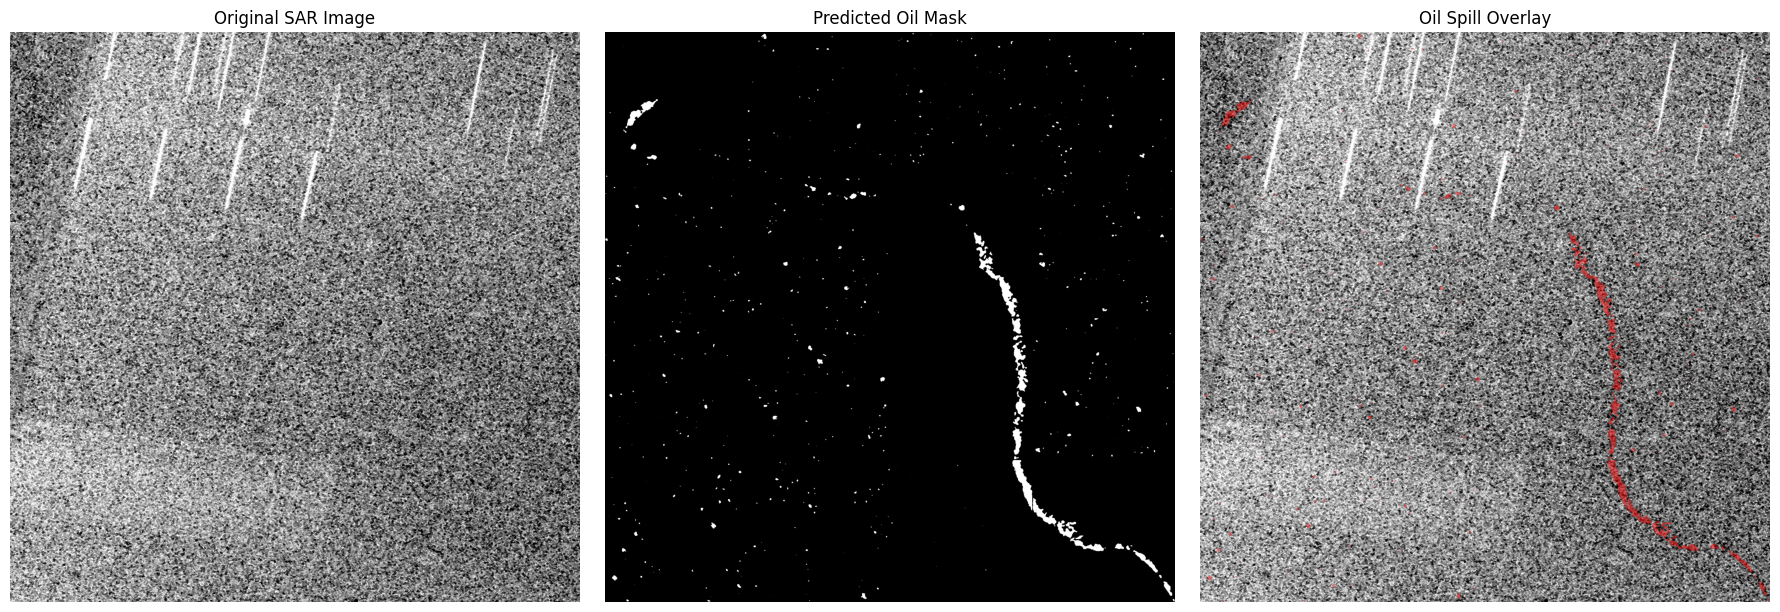

In [38]:
# ==========================================
# PHASE 1 - OIL SPILL OVERLAY
# ==========================================

import rasterio
import matplotlib.pyplot as plt
import numpy as np

TEST_IMAGE = "/content/drive/MyDrive/00168.tif"
MASK_IMAGE = "/content/drive/MyDrive/00168_oil_spill_mask.tif"

# Read SAR image
with rasterio.open(TEST_IMAGE) as src:
    sar = src.read(1).astype(np.float32)

# Read predicted mask
with rasterio.open(MASK_IMAGE) as src:
    mask = src.read(1)

# Normalize SAR for display
low = np.percentile(sar, 2)
high = np.percentile(sar, 98)

sar_display = np.clip(
    (sar - low) / (high - low),
    0,
    1
)

print("SAR shape :", sar.shape)
print("Mask shape:", mask.shape)
print("Oil pixels:", int(mask.sum()))

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)
plt.imshow(sar_display, cmap="gray")
plt.title("Original SAR Image")
plt.axis("off")

# Mask
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Oil Mask")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(sar_display, cmap="gray")
plt.imshow(
    np.ma.masked_where(mask == 0, mask),
    cmap="autumn",
    alpha=0.5
)
plt.title("Oil Spill Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()